# Day 11
## Part 1: Directed graph

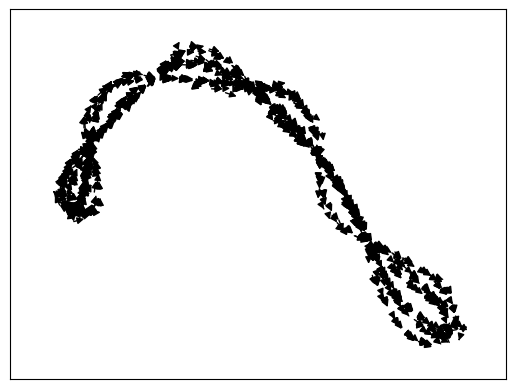

In [5]:
import networkx as nx

G = nx.DiGraph()

with open('11.txt') as f:
    for line in f.readlines():
        src, dsts = line.strip().split(': ')
        for dst in dsts.split():
            G.add_edge(src, dst)

pos = nx.spring_layout(G)
# nx.draw(G, pos)
nx.draw_networkx_edges(G, pos)
# nx.draw_networkx_labels(G, pos, font_color='white')
None

Getting the number of paths is quite easy with `networkx`:

In [6]:
paths = list(nx.all_simple_paths(G, 'you', 'out'))
len(paths)

500

## Part 2: Stops along the way

We want to find all paths from `svr` to `out` that pass by `fft` and `dac` (in either order) Naturally the optimal route is to find
```
(svr_fft + fft_dac + dac_out) + (svr_dac + dac_fft + fft_out)
```
but `networkx` is not well-optimised for this. In addition, we don't need to count paths! Instead we might count the possibilities, multiplying them out.

To ensure that we go in the correct order - such that we don't miss any paths - we will go in _topological order_.

In [7]:
from collections import Counter

def search[T](G: nx.DiGraph[T], src: T, dst: T):
    "Count the number of paths from src to dst."
    paths_from_src: Counter[T] = Counter({src: 1})
    for u in nx.topological_sort(G):
        for v in G.successors(u):
            paths_from_src[v] += paths_from_src[u]
    return paths_from_src[dst]


In [8]:
svr_fft = search(G, 'svr', 'fft')
fft_dac = search(G, 'fft', 'dac')
dac_out = search(G, 'dac', 'out')

svr_dac = search(G, 'svr', 'dac')
dac_fft = search(G, 'dac', 'fft')
fft_out = search(G, 'fft', 'out')

(svr_fft * fft_dac * dac_out) + (svr_dac * dac_fft * fft_out)

287039700129600